In [1]:
import numpy as np
from ase import Atoms
from ase.constraints import FixCom
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
import ase.units as units

from double_well_w_gradients import DoubleWell
import sys
ams_src_path = "/work/moracchl/Documents/pkg/aseams" #to change
# ams_src_path = "/ifpengpfs/scratch/work/r11/moracchl/pkg/aseams"
sys.path.append(ams_src_path)
from src.aseams.ams import AMS
from src.aseams.utils.girsanov_integrators import OverdampedLangevin,LangevinOBABO
from src.aseams.cvs import CollectiveVariables
from src.aseams.inicondssamplers import SingleWalkerSampler



In [2]:

n_ams = 1
n_rep = 25

# # Initial state.
atoms = Atoms("N2", positions=[[-0.5, 0.0, 0.0], [0.5, 0.0, 0.0]])  # Start from contact pair COM at 0,0,0
calc = DoubleWell(a = 0.05)
atoms.calc = calc

atoms.set_cell((8.0, 8.0, 8.0))

temperature_K = 500.0

# Set initial seeds
rng_ams, rng_ini, rng_dyn_ini, rng_dyn_ams = [np.random.default_rng(s) for s in [0, 0, 0, 0]]
# Setup dynamics
MaxwellBoltzmannDistribution(atoms, temperature_K=temperature_K, rng=rng_dyn_ini, force_temp=False)
atoms.set_constraint(FixCom())  # Fix the COM
dyn = LangevinOBABO(atoms,
               fixcm=True,
               timestep=1.0 * units.fs,
               temperature_K=temperature_K,
               friction=0.001 / units.fs,
               logfile=None,
               trajectory=None,
               rng=rng_dyn_ini, compute_girsanov=True)  # temperature in K

# for initial conditions, we don't want to compute girsanov weights.
dyn_ini = LangevinOBABO(atoms,
               fixcm=True,
               timestep=1.0 * units.fs,
               temperature_K=temperature_K,
               friction=0.001 / units.fs,
               logfile=None,
               trajectory=None,
               rng=rng_dyn_ini, compute_girsanov=False)  # temperature in K




In [3]:
def distance(atoms):
    return atoms.get_distance(0, 1, mic=False)
cv = CollectiveVariables(distance, distance, distance)

cv.set_r_crit("below")
cv.set_in_r_boundary(1.03)
cv.set_sigma_r_level(1.05)
cv.set_out_of_r_zone(1.5)
cv.set_p_crit("above")
cv.set_in_p_boundary(1.95)

print(dyn.atoms.get_temperature())



145.34960837645633


In [4]:

sampler = SingleWalkerSampler(dyn_ini,
                              cv,
                              cv_interval=1,
                              fixcm=True,
                              rng=rng_ini)
sampler.set_run_dir("./ini_conds_normal", append_traj=False)
sampler.set_ini_cond_dir("./ini_conds_normal", clean=False)
print(f"Génération de {50} conditions initiales brutes...")
sampler.sample(50)

Génération de 50 conditions initiales brutes...


In [5]:
probas = []
seeds_ams = rng_ams.choice(10**6, size=10)
seeds_dyn = rng_dyn_ams.choice(10**6, size=10)
for k in range(n_ams):
    rng_ams = np.random.default_rng(seeds_ams[k])
    rng_dyn_ams = np.random.default_rng(seeds_dyn[k])
    integrator = OverdampedLangevin
    
    dyn_ams = integrator(atoms,
                       fixcm=True,
                       timestep=1.0 * units.fs,
                       temperature_K=temperature_K,
                       friction=0.2 / units.fs,
                       logfile=None,
                       trajectory=None,
                       rng=rng_dyn_ams, compute_girsanov = True)
    ams = AMS(n_rep=n_rep,
              k_min=1,
              dyn=dyn_ams,
              xi=cv,
              fixcm=True,
              save_all=False,
              rc_threshold=1e-6,
              verbose=False,
              rng=rng_ams)
    ams.set_ini_cond_dir("ini_conds_normal/")
    ams._reuse_ini_conds()
    ams.set_ams_dir("AMS_" + str(k) + "/", clean=True)
    
    ams._initialize()
    ams.run()
    probas.append(ams.p_ams())

res = np.array([np.mean(probas), np.std(probas, ddof=1) / np.sqrt(len(probas))])
# np.savetxt('results.txt', res)

/work/moracchl/anaconda3/envs/aseams/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/moracchl/anaconda3/envs/aseams/lib/python3.14/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


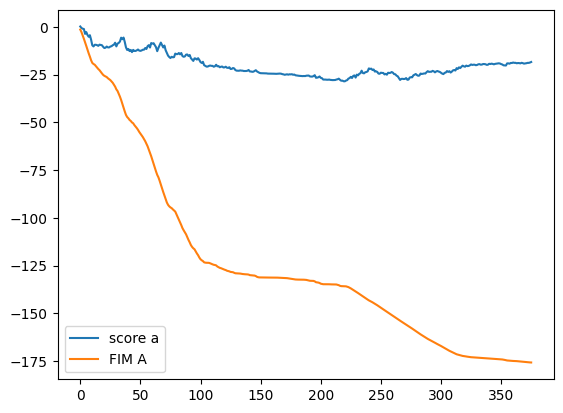

In [6]:
from ase.io import read
import matplotlib.pyplot as plt
trajectory = read("AMS_0/rep_0.traj","1:")
girsanov_score =  [atom.info['girsanov_a'] for atom in trajectory]
girsanov_FIM =  [atom.info['girsanov_A'] for atom in trajectory]
plt.plot(girsanov_score, label= "score a")
plt.plot(girsanov_FIM, label= "FIM A")
plt.legend()
plt.show()